In [1]:
import sys
sys.path.insert(0, '..')
import importlib

# Import from the package
from src import simulate, plot
from src.food import TRE
from src.params import num

%load_ext autoreload                             
%autoreload 2

In [2]:
res = simulate.run(food_fn=lambda t: TRE(t, num(2.1)), duration = 6)

2592000


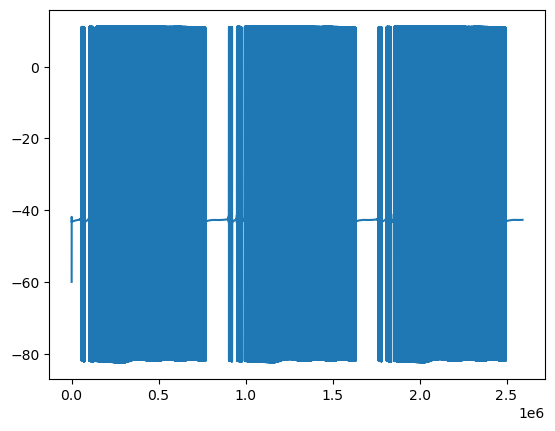

In [3]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import find_peaks

#plt.plot(vars(res)["S"])
plt.plot(vars(res)["L"])
print(len(vars(res)["S"]))

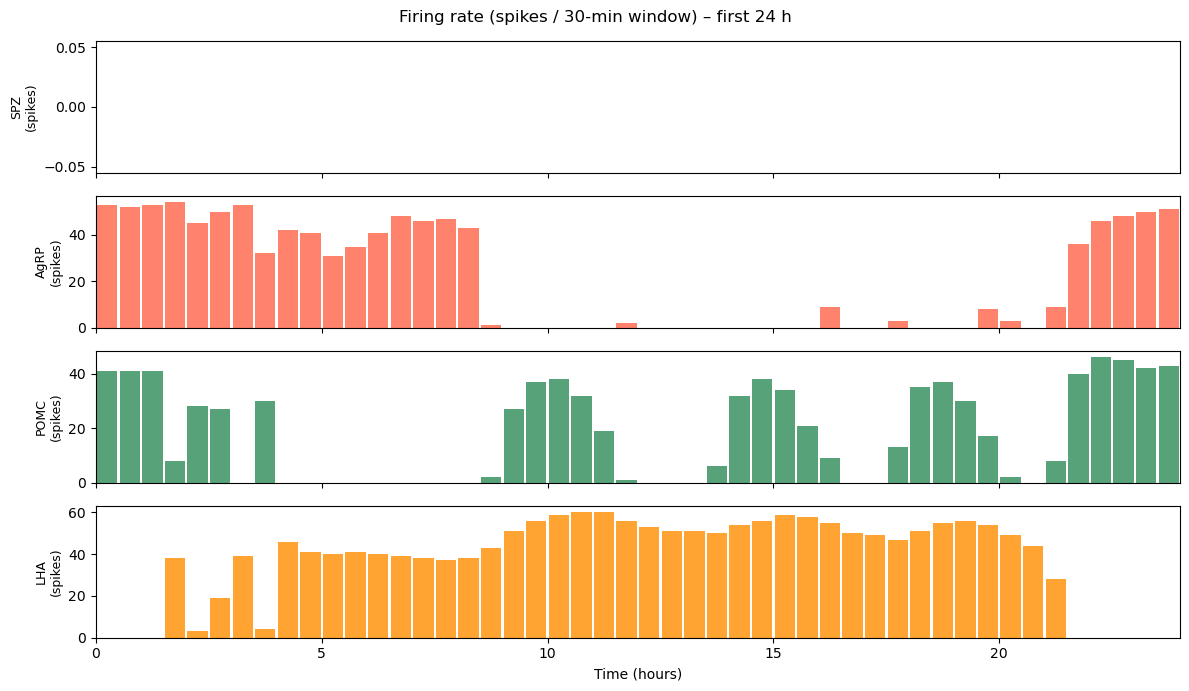

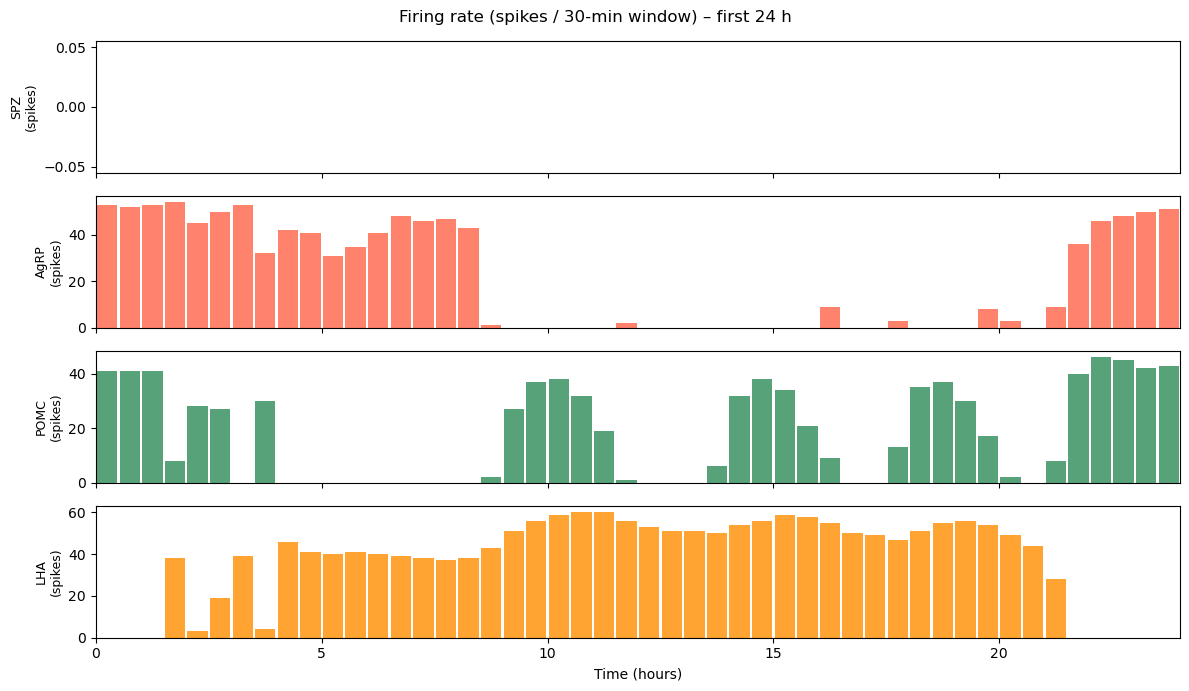

In [4]:
import matplotlib.pyplot as plt

import numpy as np
from scipy.signal import find_peaks
def plot_spike_counts(
    res,
    window_h: float = 0.5,
    hours: float = 24.0,
    peak_height: float = 0.0,
    peak_distance: int = 10,
) -> plt.Figure:
    edges   = np.arange(0.0, hours + window_h, window_h)
    centers = (edges[:-1] + edges[1:]) / 2

    def _count(voltage):
        counts = []
        for i in range(len(edges) - 1):
            t0 = edges[i]     * 3600.0
            t1 = edges[i + 1] * 3600.0
            seg = voltage[(res.t_s >= t0) & (res.t_s < t1)]
            if len(seg):
                pks, _ = find_peaks(seg, height=peak_height, distance=peak_distance)
                counts.append(len(pks))
            else:
                counts.append(0)
        return counts

    specs = [
        (_count(vars(res)["S"]), "SPZ",  "steelblue"),
        (_count(res.A), "AgRP", "tomato"),
        (_count(res.P), "POMC", "seagreen"),
        (_count(res.L), "LHA",  "darkorange"),
    ]

    fig, axes = plt.subplots(4, 1, figsize=(12, 7), sharex=True)
    fig.suptitle(f"Firing rate (spikes / {window_h*60:.0f}-min window) – first {hours:.0f} h",
                 fontsize=12)

    for ax, (counts, label, color) in zip(axes, specs):
        ax.bar(centers, counts, width=window_h * 0.9, color=color, alpha=0.8)
        ax.set_ylabel(f"{label}\n(spikes)", fontsize=9)

    axes[-1].set_xlabel("Time (hours)")
    axes[-1].set_xlim(0, hours)
    plt.tight_layout()
    return fig

plot_spike_counts(res)

In [5]:
def zscore(x):
    x = np.array(x)
    return (x - np.mean(x)) / (np.std(x) + 1e-8)

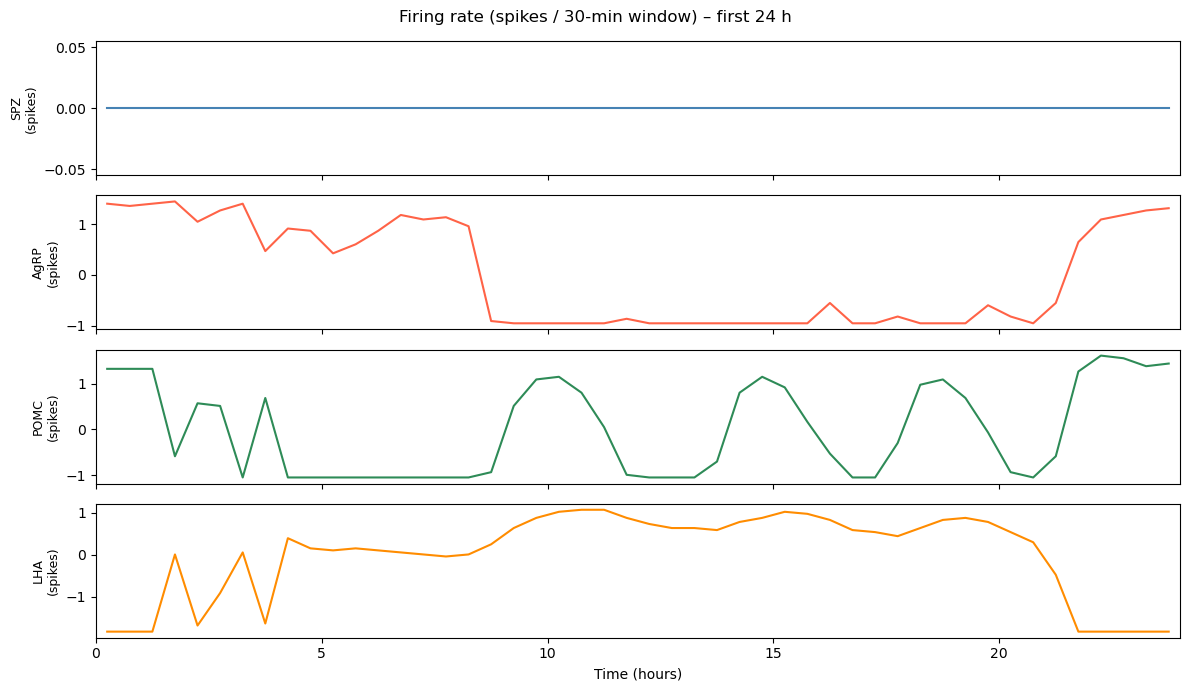

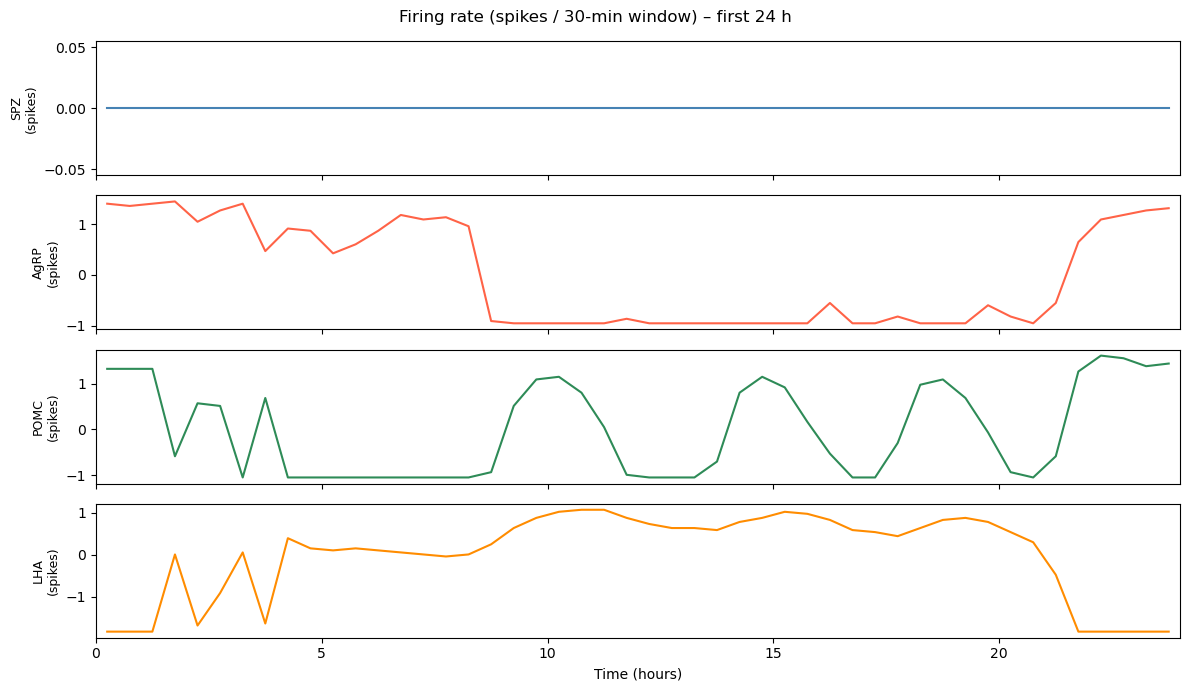

In [14]:
#z-score modification
def plot_spike_counts(
    res,
    window_h: float = 0.5,
    hours: float = 24.0,
    peak_height: float = 0.0,
    peak_distance: int = 10,
) -> plt.Figure:
    edges   = np.arange(0.0, hours + window_h, window_h)
    centers = (edges[:-1] + edges[1:]) / 2

    def _count(voltage):
        counts = []
        for i in range(len(edges) - 1):
            t0 = edges[i]     * 3600.0
            t1 = edges[i + 1] * 3600.0
            seg = voltage[(res.t_s >= t0) & (res.t_s < t1)]
            if len(seg):
                pks, _ = find_peaks(seg, height=peak_height, distance=peak_distance)
                counts.append(len(pks))
            else:
                counts.append(0)
        return counts

    specs = [
        (zscore(_count(vars(res)["S"])), "SPZ",  "steelblue"),
        (zscore(_count(res.A)), "AgRP", "tomato"),
        (zscore(_count(res.P)), "POMC", "seagreen"),
        (zscore(_count(res.L)), "LHA",  "darkorange"),
    ]

    fig, axes = plt.subplots(4, 1, figsize=(12, 7), sharex=True)
    fig.suptitle(f"Firing rate (spikes / {window_h*60:.0f}-min window) – first {hours:.0f} h",
                 fontsize=12)

    for ax, (counts, label, color) in zip(axes, specs):
        ax.plot(centers, counts, color=color)
        ax.set_ylabel(f"{label}\n(spikes)", fontsize=9)

    axes[-1].set_xlabel("Time (hours)")
    axes[-1].set_xlim(0, hours)
    plt.tight_layout()
    return fig

plot_spike_counts(res)



4


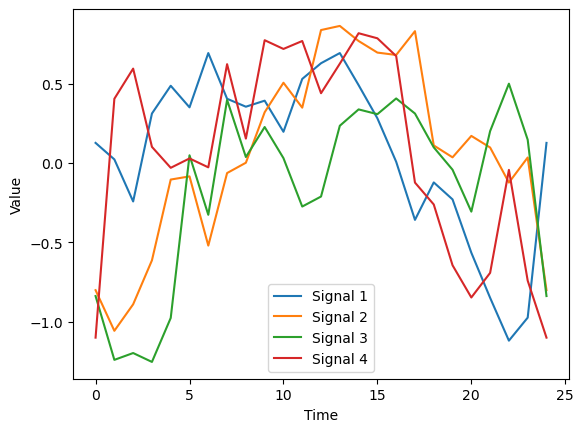

In [13]:
#experimental data
from src.experimental_data import get_experimental_results

t, data = get_experimental_results("../data/AgRP_GF-Douglass_6I.csv")

print(data.shape[1])

plt.figure()

for i in range(data.shape[1]):
    plt.plot(t, data[:, i], label=f"Signal {i+1}")

plt.xlabel("Time")
plt.ylabel("Z Score Value")
plt.legend()
plt.show()